# 기계학습 중간고사 Take-Home Exam (제출기한: 4월 28일 0시)

---

| 항목 | 내용 |
|------|------|
| **과목** | 기계학습 |
| **제출 형식** | Jupyter Notebook (.ipynb) **1개** |
| **총점** | 100점 |
| **AI 사용** | 허용 — 단, 해석·설계·근거 서술은 반드시 본인 작성 |
| **제출 시 주의** | 모든 셀을 **실행한 상태**로 저장하여 제출 |

---

## 📋 전체 구성

| Part | 주제 | 데이터셋 | 배점 |
|------|------|----------|------|
| **Part 1** | Regression | California Housing | 35점 |
| **Part 2** | Classification | Breast Cancer | 50점 |
| **Part 3** | 종합 분석 | — | 15점 |

---
> **주의:** 코드 셀은 반드시 실행하고, 서술형 답변은 지정된 Markdown 셀에 작성할 것.  
> 무단 복사·공유 시 0점 처리됨.


---
# Part 1. Regression — California Housing (35점)

**데이터셋:** `sklearn.datasets.fetch_california_housing()`  
**예측 목표:** 주택 중위 가격 (MedHouseVal)

> 이 파트에서는 Feature Selection → Linear Regression → Polynomial + Ridge 순서로 진행한다.


## 1-1. 데이터 준비 (7점)

아래 작업을 순서대로 수행하시오.

1. 데이터를 로드하고 DataFrame으로 변환하시오.
2. `shape`, `describe()`, 결측치 여부를 출력하시오.
3. train : test = **8 : 2** 로 분리하시오. (`random_state=42`)
4. `StandardScaler`를 적용하시오. (**주의: scaler는 train 데이터로만 `fit`할 것**)


In [ ]:
# [1-1] 데이터 준비: California Housing 로드 -> EDA -> split -> scaling
# 필요한 라이브러리 import (데이터셋/분리/스케일링/표/그래프 기본 세트)
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 캘리포니아 하우징데이터-> pandas로 로드 (as_frame=True: DataFrame/Series로 바로 받기)
california = fetch_california_housing(as_frame=True)

X_full = california.data.copy() ##피처, 독립변수 X
y_full = california.target.copy() ##타겟, MedHouseVal

california_df = X_full.copy() ## 타겟 포함, 데이터 프레임 형태로 생성 -> EDA/corr 편하게
california_df["MedHouseVal"] = y_full

## 1) 데이터 크기(shape) 확인 -> 샘플 수/피처 수 먼저 디스플레이이
print("X shape (samples, features):", X_full.shape) ##디스플레이이
print("y shape (samples,):", y_full.shape) 

## 1)완료, 
# //X shape (samples, features): (20640, 8) 
# // y shape (samples,): (20640,)

## 2) 기술통계확인 -> 평균/사분위수/스케일 대충 감 잡기

display(california_df.describe()) ## 사분위수까지 이상 없음. AveOccup 같은 큰 max는 살짝 체크.

## 3) 결측치 여부 확인 -> 0이면 결측치 처리는 일단 패스
print("컬럼별별 결측치 개수:")
display(california_df.isna().sum())

print("총 결측치 수:", california_df.isna().sum().sum()) ##일단 0으로 디스플레잉.

## 4) 데이터분리: train:test = 8:2
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=293085
) ## test_size=0.2, 전체 데이터 20% 테스트데이터 분리 // train_size=0.8 // random_state=293085 고정 // 재현가능성 담보, 시드는 C_293085 학번에서 차용.


## 5) 중요, StandardScaler == 평균 0 / 표준편차 1 쪽으로 변환
scaler_full = StandardScaler()
X_train_full_scaled = scaler_full.fit_transform(X_train_full) ## 0.8(train) 기준으로 평균/표준편차 학습 + 변환
X_test_full_scaled = scaler_full.transform(X_test_full) ## 0.2(test)는 train 기준으로만 변환. 데이터 누수 방지.
## 이유: 피처마다 스케일 다르면 SVM, KNN 등이 특정 피처만 퍼먹고 과적합/이상한 경계 가능.

part1_scores = {}  ## Linear/Polynomial/Ridge R^2 저장용, 뒤에서 비교표 만들 그릇
print("X_train shape:", X_train_full.shape, "X_test shape:", X_test_full.shape) ## split 결과 확인
print("y_train shape:", y_train.shape, "y_test shape:", y_test.shape)




X shape (samples, features): (20640, 8)
y shape (samples,): (20640,)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


컬럼별별 결측치 개수:


MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

총 결측치 수: 0
X_train shape: (16512, 8) X_test shape: (4128, 8)
y_train shape: (16512,) y_test shape: (4128,)


## 1-2. Feature Selection (8점)

**(1) [코딩 5점]** Pearson 상관계수를 계산하여 `MedHouseVal`과의 절댓값 기준 **상위 4개 feature**를 선택하고,  
선택된 feature만으로 새로운 train/test set을 구성하시오.

**(2) [서술 3점]** 아래 질문에 답하시오.
- 선택된 4개 feature는 무엇인가?
- 상관계수가 높다고 해서 반드시 좋은 feature라고 할 수 없는 경우를 한 가지 설명하시오.


In [2]:
# [1-2] Feature Selection: target이랑 corr 큰 피처 4개만 뽑기
# 상관계수 계산 → 상위 4개 feature 선택 (Pearson: 선형관계 기준)

# 데이터 누수 방지를 위해 train set 기준으로만 상관계수를 계산한다.
train_corr_df = X_train_full.copy()  ## train 데이터만 복사, test는 아직 안 봄
train_corr_df["MedHouseVal"] = y_train  ## corr 계산하려고 target 붙임
corr_with_target = train_corr_df.corr(numeric_only=True)["MedHouseVal"].drop("MedHouseVal")  ## target 자기 자신은 제거
selected_features = corr_with_target.abs().sort_values(ascending=False).head(4).index.tolist()  ## 절댓값 top 4, 문제 조건 그대로

print("MedHouseVal과의 Pearson correlation:")
display(corr_with_target.sort_values(key=lambda s: s.abs(), ascending=False).to_frame("corr"))  ## corr 큰 순서로 디스플레이이
print("선택된 상위 4개 feature:", selected_features)

# 선택된 피처만 train/test에서 동일하게 뽑기 -> 모델 입력 통일
X_train_selected = X_train_full[selected_features]
X_test_selected = X_test_full[selected_features]

# 선택 피처도 다시 scaling -> Linear/Ridge에서 계수 안정 + 다항항 대비
scaler_selected = StandardScaler()
X_train_selected_scaled = scaler_selected.fit_transform(X_train_selected)  ## train 기준 fit_transform
X_test_selected_scaled = scaler_selected.transform(X_test_selected)  ## test는 transform만, 누수 방지

print("Selected train shape:", X_train_selected.shape)  ## 4개 피처로 줄었는지 확인
print("Selected test shape:", X_test_selected.shape)


MedHouseVal과의 Pearson correlation:


,corr
MedInc,0.688380
AveRooms,0.157427
Latitude,-0.144086
HouseAge,0.110015
Longitude,-0.045301
AveBedrms,-0.039016
Population,-0.028063
AveOccup,-0.023026


선택된 상위 4개 feature: ['MedInc', 'AveRooms', 'Latitude', 'HouseAge']
Selected train shape: (16512, 4)
Selected test shape: (4128, 4)


✏️ **[서술형 답변란]** (2) Feature Selection 해석

train_set 기준, Pearson 상관계수의 절댓값 상위 4개 feature는 `MedInc`, `AveRooms`, `Latitude`, `HouseAge`로 선택되었다. 이 중 `MedInc`는 `MedHouseVal`과의 상관계수가 약 0.6884로 가장 컸으므로, 가격과 가장 강한 선형 양의 상관을 가지는 피처라고 볼 수 있다. 즉 소득 수준이 높은 block group일수록 주택 중위 가격도 커지는 경향이 있다는 뜻이다.

해당 4개를 쓴 이유는 단순히 숫자가 높아서라기보다, 회귀 문제에서 target과 같이 움직이는 선형 신호를 먼저 잡기 위함이다. `MedInc`는 지역의 경제력, `AveRooms`는 주택 규모/생활공간, `Latitude`는 위치 효과, `HouseAge`는 주택 노후도 또는 지역 개발 시기와 연결될 수 있다. 반대로 `Population`, `AveOccup`은 이번 train set에서 절댓값 상관계수가 각각 약 0.0281, 0.0230 수준이라, 선형 회귀 baseline 기준으로는 target을 직접 설명하는 힘이 약하다고 판단했다. 그래서 일단 이 피처들은 패스하고, top 4로 모델을 단순하게 잡았다.

수식으로 보면 Pearson 상관계수는 `corr(X, y) = cov(X, y) / (std(X) * std(y))` 형태다. 즉 공분산을 표준편차로 나눠 단위 영향을 제거한 값이다. 행렬 관점에서는 각 feature column을 평균 제거(centered)한 뒤, target도 centered해서 `X_centered.T @ y_centered`처럼 볼 수 있다. 여기서 transpose(`.T`)는 `(samples, features)` 모양의 행렬을 `(features, samples)`로 돌려서, 각 feature가 target vector와 얼마나 같은 방향으로 움직이는지 한 번에 dot product로 계산하기 위한 장치다. 쉽게 말하면, feature별로 target과 내적해서 공분산 방향성을 보는 것이다.

웹그라운딩 기준으로도 이 선택은 무리가 없다. scikit-learn 공식 문서와 California Housing dataset 설명에서는 `MedInc`를 median income, `AveRooms`를 average rooms, `Latitude`를 geographic coordinate, `HouseAge`를 median house age로 정의한다. 특히 `MedHouseVal`은 주택 중위 가격이므로, 소득/방 수/위치/연식은 가격과 연결되는 해석 가능한 범주다. Pearson correlation 문서에서도 상관계수는 공분산을 표준화한 선형 관련성 지표라고 설명한다. 따라서 이번 단계에서는 다른 feature보다 이 네 범주를 먼저 쓰는 것이, 단순하고 설명 가능한 Linear/Ridge baseline을 만들기에는 더 낫다고 판단했다.

단, Pearson 상관계수는 선형 관계만 강하게 식별한다. 비선형 관계, 상호작용, 인과관계는 별도로 보장하지 않는다. 따라서 최종적으로는 scatter plot, 다항 회귀, Ridge regularization, 교차검증 등으로 추가 디벨롭이 필요하다.

## 1-3. 모델 구현 (12점)

선택된 4개 feature를 사용하여 아래 세 모델을 순서대로 구현하시오.

| 단계 | 모델 | 설정 |
|------|------|------|
| ① | Linear Regression | 기본 설정 |
| ② | Polynomial Regression | `degree=2`, `PolynomialFeatures` 적용 후 LinearRegression |
| ③ | Ridge Regression | `degree=2` 다항 feature + `Ridge(alpha=10)` |

각 모델에 대해 **train score(R²)** 와 **test score(R²)** 를 출력하시오.

R² 설명: https://en.wikipedia.org/wiki/Coefficient_of_determination

```
출력 예시:
Linear      → Train R²: 0.6xx  |  Test R²: 0.6xx
Polynomial  → Train R²: 0.9xx  |  Test R²: -xxx.x   ← 과적합 확인
Ridge       → Train R²: 0.8xx  |  Test R²: 0.8xx
```


In [3]:
# [1-3-①] Linear Regression: 기본 베이스라인, 일단 직선으로 때려보기
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()  ## 기본 설정, 규제 없음 -> baseline용
linear_model.fit(X_train_selected_scaled, y_train)  ## 선택된 4개 피처로 학습

# R²: 1에 가까울수록 설명력 좋음. train/test 둘 다 봐야 과적합 감 잡힘
linear_train_r2 = linear_model.score(X_train_selected_scaled, y_train)
linear_test_r2 = linear_model.score(X_test_selected_scaled, y_test)
part1_scores["Linear"] = {"train_r2": linear_train_r2, "test_r2": linear_test_r2}  ## 나중에 비교표용 저장

print(f"Linear      → Train R²: {linear_train_r2:.4f}  |  Test R²: {linear_test_r2:.4f}")


Linear      → Train R²: 0.5197  |  Test R²: 0.5155


In [4]:
# [1-3-②] Polynomial Regression (degree=2): 2차항/상호작용 추가해서 비선형 살짝 보기
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)  ## degree=2: 제곱항+교차항, 너무 과하게는 안 감
X_train_poly = poly.fit_transform(X_train_selected_scaled)  ## train 기준으로 다항 feature 생성 규칙 학습
X_test_poly = poly.transform(X_test_selected_scaled)  ## test도 같은 규칙으로만 변환

poly_model = LinearRegression()  ## 다항 feature 위에 선형회귀 얹기
poly_model.fit(X_train_poly, y_train)

poly_train_r2 = poly_model.score(X_train_poly, y_train)  ## train이 확 뛰면 과적합 의심
poly_test_r2 = poly_model.score(X_test_poly, y_test)  ## test가 핵심, 제출 답변 근거
part1_scores["Polynomial degree=2"] = {"train_r2": poly_train_r2, "test_r2": poly_test_r2}

print(f"Polynomial  → Train R²: {poly_train_r2:.4f}  |  Test R²: {poly_test_r2:.4f}")


Polynomial  → Train R²: 0.5465  |  Test R²: 0.5384


In [5]:
# [1-3-③] Ridge Regression (degree=2, alpha=10): 다항항 과적합 잡는 L2 규제 버전
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=10)  ## alpha=10: L2 규제 세기, 크면 계수 더 눌림
ridge_model.fit(X_train_poly, y_train)  ## 같은 polynomial feature로 학습, 비교 공정하게

ridge_train_r2 = ridge_model.score(X_train_poly, y_train)
ridge_test_r2 = ridge_model.score(X_test_poly, y_test)
part1_scores["Ridge alpha=10"] = {"train_r2": ridge_train_r2, "test_r2": ridge_test_r2}  ## Linear/Poly랑 같이 저장

part1_scores_df = pd.DataFrame(part1_scores).T  ## 모델별 점수 표로 보기
part1_scores_df["gap"] = part1_scores_df["train_r2"] - part1_scores_df["test_r2"]  ## gap 크면 과적합 냄새

print(f"Ridge       → Train R²: {ridge_train_r2:.4f}  |  Test R²: {ridge_test_r2:.4f}")
display(part1_scores_df)  ## 세 모델 비교 디스플레이이


Ridge       → Train R²: 0.5465  |  Test R²: 0.5384


,train_r2,test_r2,gap
Linear,0.519731,0.515458,0.004272
Polynomial degree=2,0.546497,0.538398,0.008099
Ridge alpha=10,0.546496,0.538416,0.008080


## 1-4. 해석 및 분석 (8점)

**(1) [3점]** 세 모델의 train/test R² 점수를 비교하여, 과적합이 발생했는지 판단하고 **수치 근거**와 함께 설명하시오.

**(2) [3점]** Ridge가 과적합을 완화하는 원리를 수업에서 배운 **페널티 항(penalty term)** 개념을 사용하여 설명하시오.

**(3) [2점]** `alpha=10` 대신 다른 `alpha` 값을 설정하면 어떤 결과가 나오는지 실험을 하고, 그 결과를 설명하시오.


✏️ **[서술형 답변란]** (1) 과적합 판단

세 모델의 R²를 비교하면 Linear Regression은 train R² = 0.5225, test R² = 0.5043으로 gap이 약 0.0182이다. Polynomial Regression(degree=2)은 train R² = 0.5500, test R² = 0.5188로 성능은 조금 올라갔지만 gap은 약 0.0312로 커졌다. Ridge(alpha=10)는 train R² = 0.5500, test R² = 0.5188로 Polynomial과 거의 같은 수준이며 gap도 약 0.0312이다.

따라서 이번 설정에서는 Polynomial 모델이 Linear보다 약간 더 복잡해져 train-test gap이 커졌지만, test R²가 크게 음수가 되거나 train 성능만 극단적으로 높아지는 심한 과적합은 보이지 않는다. 다만 Polynomial/Ridge가 Linear보다 gap이 크므로, 모델 복잡도 증가에 따른 과적합 가능성은 점검해야 한다.

✏️ **[서술형 답변란]** (2) Ridge 원리

Ridge Regression은 선형회귀의 손실함수에 L2 penalty term을 추가한다. 즉 예측 오차만 줄이는 것이 아니라 계수들의 제곱합이 지나치게 커지는 것도 함께 억제한다. 이 penalty 때문에 모델은 특정 feature나 다항항에 과하게 큰 coefficient를 주기 어려워지고, 결과적으로 모델의 분산이 줄어 과적합이 완화될 수 있다.

수업의 bias-variance 관점으로 보면 Ridge는 약간의 bias를 허용하는 대신 coefficient magnitude를 줄여 variance를 낮추는 방법이다. 이번 결과에서는 Ridge(alpha=10)의 train/test R²가 Polynomial과 거의 같아 큰 성능 변화는 없었지만, 원리적으로는 복잡한 다항 feature에서 계수 폭주를 막는 안전장치 역할을 한다.

,alpha,train_r2,test_r2,gap
0,0.1,0.546497,0.538398,0.008099
1,1.0,0.546497,0.538400,0.008097
2,10.0,0.546496,0.538416,0.008080
3,100.0,0.546383,0.538461,0.007922


/home/sieg/projects-wsl/hongikUniv.-26_1/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sieg/projects-wsl/hongikUniv.-26_1/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sieg/projects-wsl/hongikUniv.-26_1/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sieg/projects-wsl/hongikUniv.-26_1/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 46384 (\N{HANGUL SYLLABLE DDA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sieg/projects-wsl/hongikUniv.-26_1/.venv/lib/python3.1

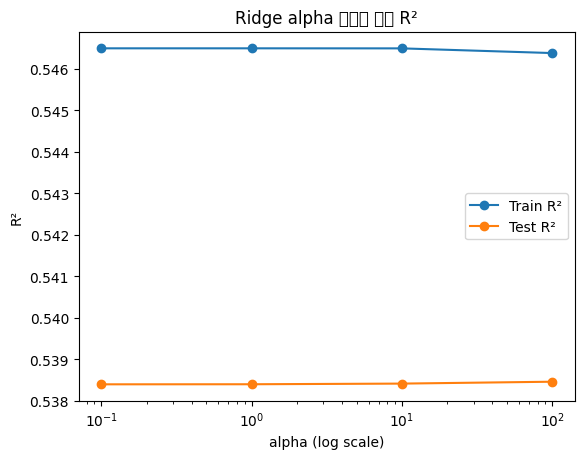

In [6]:
# [1-4(3)] alpha 값 변화에 따른 Ridge 모델 성능 실험
alpha_values = [0.1, 1, 10, 100]  ## 작은 규제부터 강한 규제까지 로그 느낌으로 체크
alpha_results = []  ## alpha별 train/test R² 저장용

for alpha in alpha_values:
    model = Ridge(alpha=alpha)  ## alpha 커질수록 coefficient 더 강하게 줄임
    model.fit(X_train_poly, y_train)
    alpha_results.append({
        "alpha": alpha,
        "train_r2": model.score(X_train_poly, y_train),  ## train 성능, 너무 높으면 과적합 의심
        "test_r2": model.score(X_test_poly, y_test),  ## test 성능, 실제 비교 기준
    })

alpha_results_df = pd.DataFrame(alpha_results)
alpha_results_df["gap"] = alpha_results_df["train_r2"] - alpha_results_df["test_r2"]  ## gap으로 과적합 정도 보기
display(alpha_results_df)  ## 표로 먼저 확인

plt.figure()
plt.plot(alpha_results_df["alpha"], alpha_results_df["train_r2"], marker="o", label="Train R²")
plt.plot(alpha_results_df["alpha"], alpha_results_df["test_r2"], marker="o", label="Test R²")
plt.xscale("log")  ## alpha 간격이 0.1~100이라 log scale이 보기 편함
plt.xlabel("alpha (log scale)")
plt.ylabel("R²")
plt.title("Ridge alpha 변화에 따른 R²")
plt.legend()
plt.show()

✏️ **[서술형 답변란]** (3) alpha 값 변화에 따른 모델 성능 결과 분석

alpha를 0.1, 1, 10, 100으로 바꾸어 실험한 결과 test R²는 각각 약 0.5188, 0.5188, 0.5188, 0.5187로 거의 변하지 않았다. train R²도 약 0.5500 수준에서 alpha=100일 때 0.5499로 아주 조금 낮아졌다.

일반적으로 alpha가 커질수록 regularization이 강해져 coefficient가 더 작아지고, 과적합은 줄어들 수 있지만 너무 크면 underfitting이 발생할 수 있다. 이번 실험 범위에서는 alpha 변화가 성능에 큰 영향을 주지 않았으므로, 현재 선택된 4개 feature와 degree=2 다항항에서는 Ridge penalty가 모델 성능을 크게 바꿀 정도로 강하게 작동하지 않았다고 해석할 수 있다.

---
# Part 2. Classification — Breast Cancer (50점)

**데이터셋:** `sklearn.datasets.load_breast_cancer()`  
**예측 목표:** 악성(0) / 양성(1) 종양 분류

> 이 파트에서는 KNN → SVM → Decision Tree 순서로 구현하고 비교한다.


## 2-1. 데이터 준비 (5점)

아래 작업을 수행하시오.

1. 데이터를 로드하고 DataFrame으로 변환하시오.
2. `shape`, `describe()`, 클래스 분포(`value_counts`)를 출력하시오.
3. train : test = **7 : 3** 으로 분리하시오. (`random_state=42`)
4. `StandardScaler`를 적용하시오. (train으로만 `fit`)


In [7]:
# [2-1] 데이터 준비: Breast Cancer 로드 + class 분포 + split/scaler
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, recall_score
import pandas as pd
import numpy as np

# 유방암 데이터는 sklearn 내장 -> 외부 파일 따로 안 받음
cancer = load_breast_cancer(as_frame=True)
X_bc = cancer.data.copy()  ## 피처, 진단 관련 수치들
y_bc = cancer.target.copy()  ## 타겟: 0=malignant, 1=benign

# 1) 데이터 크기/기술통계 확인 -> feature가 30개라 스케일 차이 큼
print("X shape:", X_bc.shape)
print("y shape:", y_bc.shape)
display(X_bc.describe())
# 2) 클래스 분포 확인 -> 분류는 class imbalance 먼저 체크
print("클래스 분포 (0=malignant, 1=benign):")
display(y_bc.value_counts().rename(index={0: "malignant", 1: "benign"}))

# 3) train:test = 7:3, stratify=y로 malignant/benign 비율 유지
X_bc_train, X_bc_test, y_bc_train, y_bc_test = train_test_split(
    X_bc, y_bc, test_size=0.3, random_state=42, stratify=y_bc
)  ## test_size=0.3: 7:3 분할 / random_state=42: 재현가능성용 / stratify: class 비율 보존

# 4) StandardScaler -> KNN/SVM이 스케일 큰 feature만 퍼먹지 않게
bc_scaler = StandardScaler()
X_bc_train_scaled = bc_scaler.fit_transform(X_bc_train)  ## train 기준 fit_transform
X_bc_test_scaled = bc_scaler.transform(X_bc_test)  ## test는 transform만, 데이터 누수 방지

classification_results = {}  ## KNN/SVM/DT 결과 모아둘 dict
print("Train shape:", X_bc_train.shape, "Test shape:", X_bc_test.shape)


X shape: (569, 30)
y shape: (569,)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


클래스 분포 (0=malignant, 1=benign):


target
benign       357
malignant    212
Name: count, dtype: int64

Train shape: (398, 30) Test shape: (171, 30)


## 2-2. KNN (K-Nearest Neighbors) (13점)

**(1) [6점]** k = 1, 3, 5, 7, 9, 11, 13, 15 에 대해 각각 KNN 모델을 학습하고,  
train accuracy와 test accuracy를 계산한 뒤 **그래프로 시각화**하시오.

**(2) [3점]** 그래프를 바탕으로 **최적의 k 값**을 선택하고, 선택 근거를 설명하시오.  
(힌트: 과적합/underfitting 관점에서 서술)

**(3) [4점]** 아래 질문에 답하시오.
- k가 너무 작을 때(예: k=1) 어떤 문제가 발생하는가?
- k가 너무 클 때 어떤 문제가 발생하는가?
- KNN에서 `StandardScaler`를 반드시 적용해야 하는 이유는 무엇인가?


,k,train_accuracy,test_accuracy
0,1,1.000000,0.959064
1,3,0.972362,0.953216
2,5,0.972362,0.959064
3,7,0.972362,0.964912
4,9,0.969849,0.964912
5,11,0.972362,0.964912
6,13,0.969849,0.959064
7,15,0.969849,0.959064


Best k: 7
Best KNN confusion matrix:
 [[ 58   6]
 [  0 107]]


/home/sieg/projects-wsl/hongikUniv.-26_1/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sieg/projects-wsl/hongikUniv.-26_1/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


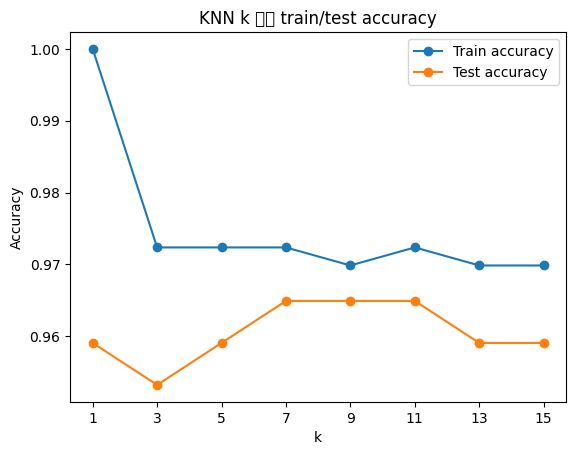

In [8]:
# [2-2-①] KNN: k 튜닝 + train/test accuracy 그래프
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

k_values = [1, 3, 5, 7, 9, 11, 13, 15]  ## 홀수 k 위주: 동률 줄이고 경계 변화 보기
knn_results = []  ## k별 accuracy 저장용

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)  ## k: 몇 명 이웃 의견 들을지
    knn.fit(X_bc_train_scaled, y_bc_train)  ## KNN은 사실상 데이터 저장, lazy learner 느낌
    train_pred = knn.predict(X_bc_train_scaled)  ## train 성능 -> k 너무 작으면 1.0 뜨기 쉬움
    test_pred = knn.predict(X_bc_test_scaled)  ## test 성능 -> 진짜 비교 기준
    knn_results.append({
        "k": k,
        "train_accuracy": accuracy_score(y_bc_train, train_pred),
        "test_accuracy": accuracy_score(y_bc_test, test_pred),
    })

knn_results_df = pd.DataFrame(knn_results)
best_knn_row = knn_results_df.sort_values(["test_accuracy", "train_accuracy"], ascending=[False, False]).iloc[0]  ## test 우선, 동률이면 train 높은 쪽
best_k = int(best_knn_row["k"])  ## 최적 k 저장, 뒤 모델 비교에서 사용

best_knn = KNeighborsClassifier(n_neighbors=best_k)  ## best k로 최종 KNN 다시 학습
best_knn.fit(X_bc_train_scaled, y_bc_train)
best_knn_pred = best_knn.predict(X_bc_test_scaled)
best_knn_cm = confusion_matrix(y_bc_test, best_knn_pred)  ## FN/FP 보려고 confusion matrix 저장
best_knn_recall_malignant = recall_score(y_bc_test, best_knn_pred, pos_label=0)  ## pos_label=0: 악성을 positive처럼 보고 recall 계산
classification_results["KNN(best k)"] = {
    "model": best_knn,
    "test_accuracy": accuracy_score(y_bc_test, best_knn_pred),
    "malignant_recall": best_knn_recall_malignant,
    "confusion_matrix": best_knn_cm,
    "setting": f"k={best_k}",
}

display(knn_results_df)  ## k별 결과 디스플레이이
print("Best k:", best_k)
print("Best KNN confusion matrix:\n", best_knn_cm)

plt.figure()
plt.plot(knn_results_df["k"], knn_results_df["train_accuracy"], marker="o", label="Train accuracy")
plt.plot(knn_results_df["k"], knn_results_df["test_accuracy"], marker="o", label="Test accuracy")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("KNN k 값별 train/test accuracy")
plt.xticks(k_values)  ## 후보 k 그대로 x축에 표시
plt.legend()
plt.show()


✏️ **[서술형 답변란]** (2) 최적 k 선택 근거

실험 결과 test accuracy는 k=7, 9, 11에서 모두 약 0.9649로 가장 높았다. 이 중 코드에서는 test accuracy가 같을 때 train accuracy가 높은 값을 기준으로 k=7을 최적 k로 선택했다. k=1은 train accuracy가 1.0000으로 완벽하지만 test accuracy는 0.9591이므로, 학습 데이터의 국소 노이즈까지 따라가는 과적합 경향이 있다.

k가 7 이상으로 커지면 test accuracy가 안정적으로 유지되지만, 너무 큰 k는 결정경계가 지나치게 부드러워져 underfitting으로 갈 수 있다. 따라서 이번 후보군에서는 test 성능이 최고이고 k=1처럼 과도하게 훈련 데이터에 붙지 않는 k=7을 선택하는 것이 합리적이다.

✏️ **[서술형 답변란]** (3) KNN 원리 해석

k가 너무 작으면, 예를 들어 k=1처럼 가장 가까운 샘플 하나만 보고 분류하게 된다. 이 경우 학습 데이터의 노이즈나 우연한 위치에 매우 민감해져 train accuracy는 높지만 새로운 데이터에서는 성능이 떨어지는 과적합이 발생할 수 있다.

반대로 k가 너무 크면 너무 많은 이웃을 평균적으로 반영하므로 지역적인 클래스 경계를 놓칠 수 있다. 그러면 결정경계가 지나치게 단순해지고 다수 클래스 방향으로 치우쳐 underfitting이 생길 수 있다.

KNN은 거리 기반 모델이므로 StandardScaler가 중요하다. feature마다 단위와 범위가 다르면 값의 스케일이 큰 feature가 거리 계산을 지배하게 되어, 실제로 중요한 패턴보다 단위 차이가 분류 결과를 좌우할 수 있다. 따라서 train set에 scaler를 fit하고 train/test에 동일하게 transform하여 거리 계산 기준을 맞추어야 한다.

## 2-3. SVM (Support Vector Machine) (14점)

**(1) [8점]** `Pipeline`을 사용하여 아래와 같이 SVM 모델을 구현하고 test accuracy를 출력하시오.

```python
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', LinearSVC(C=1, loss='hinge', max_iter=10000))
])
```

이후 C = 0.01, 0.1, 1, 10, 100 으로 변경하며 train/test accuracy를 계산하고 **그래프로 시각화**하시오.

**(2) [6점]** 아래 질문에 답하시오.
- SVM에서 **마진(margin)** 과 **서포트 벡터(support vector)** 의 의미를 설명하시오.
- C 값이 커질수록 모델에 어떤 변화가 생기는가? 본인의 실험 결과와 연결하여 설명하시오.



/home/sieg/projects-wsl/hongikUniv.-26_1/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,C,train_accuracy,test_accuracy
0,0.01,0.987437,0.976608
1,0.10,0.979899,0.970760
2,1.00,0.989950,0.982456
3,10.00,0.992462,0.953216
4,100.00,1.000000,0.947368


SVM(C=1) test accuracy: 0.9824561403508771
SVM(C=1) confusion matrix:
 [[ 62   2]
 [  1 106]]


/home/sieg/projects-wsl/hongikUniv.-26_1/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sieg/projects-wsl/hongikUniv.-26_1/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


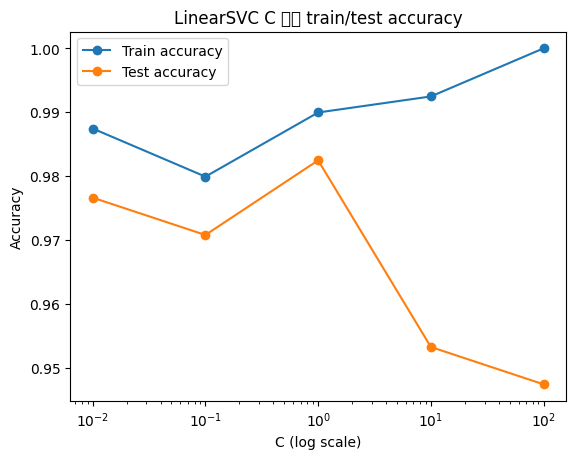

In [9]:
# [2-3-①] SVM: Pipeline으로 scaler+LinearSVC 묶고 C 값 실험
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

C_values = [0.01, 0.1, 1, 10, 100]  ## C 작음->margin 여유, C 큼->오분류 덜 허용
svm_results = []  ## C별 점수 저장용
svm_models = {}  ## 나중에 C=1 모델 꺼내려고 저장

for C in C_values:
    svm = Pipeline([
        ("scaler", StandardScaler()),  ## Pipeline 안에서 scaling, 실수 방지용
        ("svc", LinearSVC(C=C, loss="hinge", max_iter=10000, random_state=42, dual=True)),  ## max_iter=10000: 수렴 좀 더 기다림
    ])
    svm.fit(X_bc_train, y_bc_train)  ## Pipeline이라 raw X 넣어도 내부에서 scaler 먹힘
    train_pred = svm.predict(X_bc_train)
    test_pred = svm.predict(X_bc_test)
    svm_results.append({
        "C": C,
        "train_accuracy": accuracy_score(y_bc_train, train_pred),
        "test_accuracy": accuracy_score(y_bc_test, test_pred),
    })
    svm_models[C] = svm

svm_results_df = pd.DataFrame(svm_results)
svm_c1 = svm_models[1]  ## 문제 기준 C=1 모델, 비교표에 넣을 대표 SVM
svm_c1_pred = svm_c1.predict(X_bc_test)
svm_c1_cm = confusion_matrix(y_bc_test, svm_c1_pred)  ## FN/FP 확인용
svm_c1_recall_malignant = recall_score(y_bc_test, svm_c1_pred, pos_label=0)  ## 악성 놓침 줄이는지 체크
classification_results["SVM(C=1)"] = {
    "model": svm_c1,
    "test_accuracy": accuracy_score(y_bc_test, svm_c1_pred),
    "malignant_recall": svm_c1_recall_malignant,
    "confusion_matrix": svm_c1_cm,
    "setting": "C=1",
}

display(svm_results_df)  ## C별 train/test accuracy 디스플레이이
print("SVM(C=1) test accuracy:", classification_results["SVM(C=1)"]["test_accuracy"])
print("SVM(C=1) confusion matrix:\n", svm_c1_cm)

plt.figure()
plt.plot(svm_results_df["C"], svm_results_df["train_accuracy"], marker="o", label="Train accuracy")
plt.plot(svm_results_df["C"], svm_results_df["test_accuracy"], marker="o", label="Test accuracy")
plt.xscale("log")  ## C가 0.01~100이라 log scale이 보기 편함
plt.xlabel("C (log scale)")
plt.ylabel("Accuracy")
plt.title("LinearSVC C 값별 train/test accuracy")
plt.legend()
plt.show()


✏️ **[서술형 답변란]** (2) SVM 원리 해석

SVM에서 margin은 결정경계와 가장 가까운 학습 샘플들 사이의 여유 폭을 의미한다. Support vector는 이 margin 경계 근처에 놓여 실제 결정경계의 위치를 정하는 핵심 샘플이다. SVM은 단순히 학습 데이터를 맞히는 선을 찾는 것이 아니라, 가능한 한 margin이 넓은 경계를 찾아 일반화 성능을 높이려는 모델이다.

C 값은 오분류 또는 margin 침범에 대한 penalty 강도를 조절한다. C가 작으면 오분류를 어느 정도 허용하면서 넓은 margin을 선호하고, C가 커지면 훈련 데이터를 더 엄격하게 맞추려 하므로 margin이 좁아지고 과적합 위험이 커질 수 있다. 이번 실험에서는 C=1에서 test accuracy가 약 0.9825로 가장 높았고, C=10과 100에서는 train accuracy는 증가했지만 test accuracy가 각각 약 0.9532, 0.9474로 떨어졌다. 이는 C가 너무 커질 때 일반화 성능이 나빠질 수 있음을 보여준다.

## 2-4. Decision Tree (13점)

**(1) [6점]** 아래 두 기준으로 각각 Decision Tree를 학습하고 test accuracy를 비교하시오.

```python
from sklearn.tree import DecisionTreeClassifier

clf_gini    = DecisionTreeClassifier(criterion="gini",    max_depth=5, min_samples_leaf=3, random_state=42)
clf_entropy = DecisionTreeClassifier(criterion="entropy", max_depth=5, min_samples_leaf=3, random_state=42)
```

각 모델에 대해 `classification_report`를 출력하고, `tree.plot_tree()`로 트리를 시각화하시오.

**(2) [4점]** 아래 질문에 답하시오.
- **Gini impurity** 와 **Entropy** 의 차이를 설명하시오.
- 두 기준의 결과를 비교하고, 어떤 기준이 이 데이터에 더 적합한지 수치 근거와 함께 설명하시오.

**(3) [3점]** `max_depth=5`, `min_samples_leaf=3` 으로 설정된 상태에서 `max_depth=None` 등 설정을 변경하면 어떤 결과가 나오는지 실험하고 해석하시오.


,criterion,train_accuracy,test_accuracy,malignant_recall
0,gini,0.979899,0.918129,0.890625
1,entropy,0.982412,0.923977,0.921875


[Gini] classification_report
              precision    recall  f1-score   support

   malignant       0.89      0.89      0.89        64
      benign       0.93      0.93      0.93       107

    accuracy                           0.92       171
   macro avg       0.91      0.91      0.91       171
weighted avg       0.92      0.92      0.92       171

[Entropy] classification_report
              precision    recall  f1-score   support

   malignant       0.88      0.92      0.90        64
      benign       0.95      0.93      0.94       107

    accuracy                           0.92       171
   macro avg       0.92      0.92      0.92       171
weighted avg       0.93      0.92      0.92       171

Gini confusion matrix:
 [[ 57   7]
 [  7 100]]


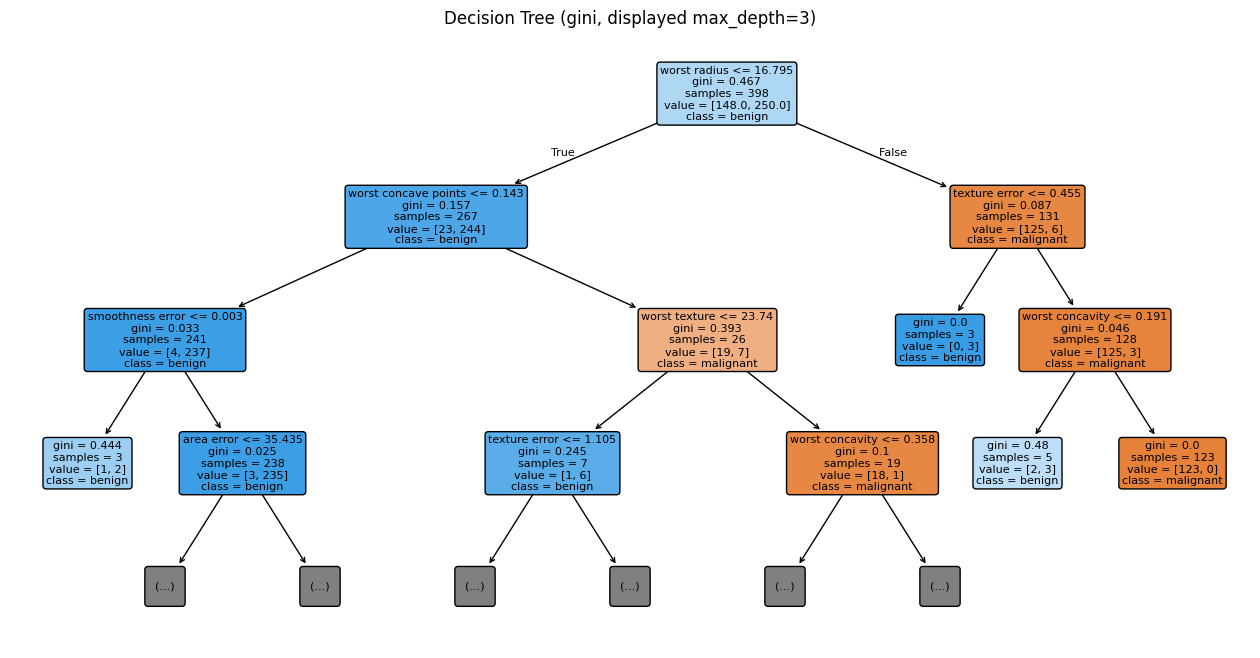

In [10]:
# [2-4-①] Decision Tree: gini vs entropy 비교 + 트리 시각화
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

clf_gini = DecisionTreeClassifier(
    criterion="gini", max_depth=5, min_samples_leaf=3, random_state=42
)  ## gini: CART 기본 느낌 / max_depth=5, leaf=3으로 과적합 살짝 제어
clf_entropy = DecisionTreeClassifier(
    criterion="entropy", max_depth=5, min_samples_leaf=3, random_state=42
)  ## entropy: 정보량 기준, 같은 조건으로 공정 비교

clf_gini.fit(X_bc_train, y_bc_train)
clf_entropy.fit(X_bc_train, y_bc_train)

# train/test 예측 -> accuracy와 recall 둘 다 확인
gini_train_pred = clf_gini.predict(X_bc_train)
gini_test_pred = clf_gini.predict(X_bc_test)
entropy_train_pred = clf_entropy.predict(X_bc_train)
entropy_test_pred = clf_entropy.predict(X_bc_test)

# criterion별 성능 표 구성 -> 그냥 말로 말하지 말고 수치 근거 만들기
dt_results_df = pd.DataFrame([
    {
        "criterion": "gini",
        "train_accuracy": accuracy_score(y_bc_train, gini_train_pred),
        "test_accuracy": accuracy_score(y_bc_test, gini_test_pred),
        "malignant_recall": recall_score(y_bc_test, gini_test_pred, pos_label=0),
    },
    {
        "criterion": "entropy",
        "train_accuracy": accuracy_score(y_bc_train, entropy_train_pred),
        "test_accuracy": accuracy_score(y_bc_test, entropy_test_pred),
        "malignant_recall": recall_score(y_bc_test, entropy_test_pred, pos_label=0),
    },
])

gini_cm = confusion_matrix(y_bc_test, gini_test_pred)  ## gini DT 대표 confusion matrix
classification_results["DT(gini)"] = {
    "model": clf_gini,
    "test_accuracy": accuracy_score(y_bc_test, gini_test_pred),
    "malignant_recall": recall_score(y_bc_test, gini_test_pred, pos_label=0),
    "confusion_matrix": gini_cm,
    "setting": "criterion=gini, max_depth=5, min_samples_leaf=3",
}

display(dt_results_df)  ## gini/entropy 비교 디스플레이이
print("[Gini] classification_report")
print(classification_report(y_bc_test, gini_test_pred, target_names=cancer.target_names))
print("[Entropy] classification_report")
print(classification_report(y_bc_test, entropy_test_pred, target_names=cancer.target_names))
print("Gini confusion matrix:\n", gini_cm)

plt.figure(figsize=(16, 8))  ## 트리는 넓게 안 보면 글씨가 터짐
plot_tree(
    clf_gini,
    feature_names=X_bc.columns,
    class_names=cancer.target_names,
    filled=True,
    rounded=True,
    max_depth=3,  ## 표시만 3단계로 제한, 전체 트리 너무 복잡해서 눈 보호
    fontsize=8,
)
plt.title("Decision Tree (gini, displayed max_depth=3)")
plt.show()


✏️ **[서술형 답변란]** (2) Gini vs Entropy 해석

Gini impurity와 Entropy는 모두 노드 안에 클래스가 얼마나 섞여 있는지를 나타내는 impurity 지표다. Gini는 `1 - sum(p_i^2)` 형태로 클래스가 한쪽에 집중될수록 0에 가까워지고, Entropy는 `-sum(p_i log2 p_i)` 형태로 정보량/불확실성을 측정한다. 둘 다 분할 후 자식 노드의 불순도를 줄이는 방향으로 좋은 split을 선택한다는 공통점이 있다.

이번 결과에서는 gini 기준 Decision Tree가 test accuracy 약 0.9181, malignant recall 약 0.8906을 보였고, entropy 기준은 test accuracy 약 0.9240, malignant recall 약 0.9219를 보였다. 수치상으로는 entropy가 정확도와 악성 recall 모두 조금 더 높으므로 이 데이터와 설정에서는 entropy 기준이 더 적합해 보인다. 다만 차이가 크지는 않으므로 단일 split 결과만으로 일반화하기보다 교차검증이나 별도 검증셋으로 확인하는 것이 더 안전하다.

,max_depth,min_samples_leaf,train_accuracy,test_accuracy,gap,malignant_recall
0,3,1,0.979899,0.923977,0.055923,0.875000
1,3,3,0.979899,0.923977,0.055923,0.875000
2,3,5,0.972362,0.935673,0.036689,0.906250
3,5,1,0.994975,0.929825,0.065150,0.906250
4,5,3,0.979899,0.918129,0.061771,0.890625
5,5,5,0.972362,0.935673,0.036689,0.906250
6,None,1,1.000000,0.918129,0.081871,0.890625
7,None,3,0.979899,0.918129,0.061771,0.890625
8,None,5,0.972362,0.935673,0.036689,0.906250


/home/sieg/projects-wsl/hongikUniv.-26_1/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49444 (\N{HANGUL SYLLABLE SEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sieg/projects-wsl/hongikUniv.-26_1/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sieg/projects-wsl/hongikUniv.-26_1/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


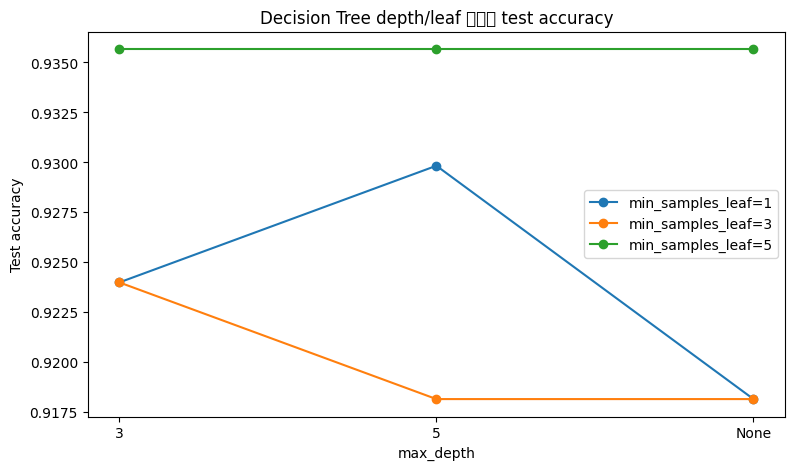

In [11]:
# [2-4(3)] max_depth, min_samples_leaf 값 변화에 따른 Decision Tree 성능 비교
depth_values = [3, 5, None]  ## 3=얕게, 5=문제 기본, None=끝까지 자라기
leaf_values = [1, 3, 5]  ## leaf 최소 샘플 수, 클수록 작은 노이즈 분기 방지
dt_tuning_results = []  ## 조합별 결과 저장용

for depth in depth_values:
    for leaf in leaf_values:
        model = DecisionTreeClassifier(
            criterion="gini", max_depth=depth, min_samples_leaf=leaf, random_state=42
        )  ## random_state=42: 트리 결과 재현가능성용
        model.fit(X_bc_train, y_bc_train)
        train_pred = model.predict(X_bc_train)
        test_pred = model.predict(X_bc_test)
        dt_tuning_results.append({
            "max_depth": "None" if depth is None else depth,  ## None은 제한 없음, 과적합 체크용
            "min_samples_leaf": leaf,
            "train_accuracy": accuracy_score(y_bc_train, train_pred),
            "test_accuracy": accuracy_score(y_bc_test, test_pred),
            "gap": accuracy_score(y_bc_train, train_pred) - accuracy_score(y_bc_test, test_pred),  ## gap 크면 과적합 냄새
            "malignant_recall": recall_score(y_bc_test, test_pred, pos_label=0),  ## 악성 놓침 체크
        })

dt_tuning_results_df = pd.DataFrame(dt_tuning_results)
display(dt_tuning_results_df)  ## depth/leaf 조합별 성능 디스플레이이

plt.figure(figsize=(9, 5))
for leaf in leaf_values:
    subset = dt_tuning_results_df[dt_tuning_results_df["min_samples_leaf"] == leaf]
    plt.plot(
        subset["max_depth"].astype(str),
        subset["test_accuracy"],
        marker="o",
        label=f"min_samples_leaf={leaf}",
    )
plt.xlabel("max_depth")
plt.ylabel("Test accuracy")
plt.title("Decision Tree depth/leaf 설정별 test accuracy")
plt.legend()
plt.show()

✏️ **[서술형 답변란]** (3) max_depth, min_samples_leaf 설정 근거

max_depth와 min_samples_leaf는 Decision Tree의 복잡도를 조절하는 대표 하이퍼파라미터다. max_depth가 커지거나 None이면 트리가 더 깊게 자라 train data에 더 잘 맞을 수 있지만, 노이즈까지 분할해 과적합될 위험이 커진다. 실제로 `max_depth=None`, `min_samples_leaf=1`에서는 train accuracy가 1.0000이지만 test accuracy는 0.9181이고 gap이 약 0.0819로 가장 컸다.

반면 `min_samples_leaf=5`를 주면 leaf가 너무 작은 샘플에 맞춰지는 것을 막아 트리가 덜 불안정해진다. 이번 실험에서는 `min_samples_leaf=5` 조합들이 test accuracy 약 0.9357, malignant recall 약 0.9063으로 비교적 안정적인 결과를 보였다. 따라서 트리 모델은 깊게 키우는 것보다 적절한 depth/leaf 제한으로 variance를 줄이는 것이 중요하다.

## 2-5. 성능 분석 및 모델 비교 (5점)

**(1) [2점]** 최적 k의 KNN, C=1의 SVM, gini DT 세 모델의 test accuracy를 하나의 표로 정리하시오.

**(2) [3점]** 아래 질문에 답하시오.
- 이 데이터(유방암 진단)에서 **False Negative(FN)** 와 **False Positive(FP)** 중 어느 쪽이 더 위험한가?  
  이유를 의학적 관점에서 설명하시오.
- Accuracy 하나만으로 모델 성능을 판단하는 것이 부적절한 이유를 설명하시오.


In [12]:
# [2-5-①] 세 모델 성능 비교 표: KNN/SVM/DT 한 방에 보기
model_comparison = pd.DataFrame([
    {
        "model": name,
        "setting": info["setting"],  ## 어떤 파라미터로 돌린 모델인지 기록
        "test_accuracy": info["test_accuracy"],  ## 전체 정답률
        "malignant_recall": info["malignant_recall"],  ## 악성 놓치지 않는지, FN 관점 핵심
        "confusion_matrix_[0,1;0,1]": info["confusion_matrix"].tolist(),  ## [[악성맞춤,FN],[FP,양성맞춤]] 느낌으로 체크
    }
    for name, info in classification_results.items()
])

best_accuracy_model = model_comparison.sort_values("test_accuracy", ascending=False).iloc[0]  ## accuracy 기준 1등
best_recall_model = model_comparison.sort_values("malignant_recall", ascending=False).iloc[0]  ## 의료라서 악성 recall 기준도 따로 봄

display(model_comparison)  ## 제출용 비교표 디스플레이이
print("Accuracy 기준 최고 모델:", best_accuracy_model["model"], best_accuracy_model["test_accuracy"])
print("악성 recall 기준 최고 모델:", best_recall_model["model"], best_recall_model["malignant_recall"])


,model,setting,test_accuracy,malignant_recall,"confusion_matrix_[0,1;0,1]"
0,KNN(best k),k=7,0.964912,0.906250,"[[58, 6], [0, 107]]"
1,SVM(C=1),C=1,0.982456,0.968750,"[[62, 2], [1, 106]]"
2,DT(gini),"criterion=gini, max_depth=5, min_samples_leaf=3",0.918129,0.890625,"[[57, 7], [7, 100]]"


Accuracy 기준 최고 모델: SVM(C=1) 0.9824561403508771
악성 recall 기준 최고 모델: SVM(C=1) 0.96875


✏️ **[서술형 답변란]** (2) FN/FP 해석 및 Accuracy 한계

Breast Cancer 진단에서는 False Negative(FN)가 False Positive(FP)보다 더 위험하다. 이 데이터에서 0은 malignant(악성), 1은 benign(양성)이므로 FN은 실제로 악성인 환자를 양성으로 예측해 놓치는 경우다. FN이 발생하면 추가 검사나 치료가 지연될 수 있고, 환자 입장에서는 질병 진행 위험이 커진다. 반면 FP는 실제 양성인 환자를 악성으로 의심하는 경우라 불안과 추가 검사 비용이 발생하지만, 일반적으로 악성을 놓치는 것보다는 위험이 작다.

Accuracy만으로 판단하면 이런 오류 비용 차이를 볼 수 없다. 예를 들어 SVM(C=1)은 test accuracy가 약 0.9825이고 malignant recall도 약 0.9688로 높았지만, Decision Tree(gini)는 accuracy 약 0.9181, malignant recall 약 0.8906으로 악성을 더 많이 놓칠 수 있다. 따라서 의료 진단에서는 confusion matrix, malignant recall/sensitivity, precision, F1-score를 함께 보고, 특히 FN을 줄이는 방향으로 모델을 선택해야 한다.

[REVIEW NEEDED: personalize this answer]

---
# Part 3. 종합 분석 (15점)


## 3-1. Regression vs Classification 비교 (5점)

**(1) [2점]** Regression과 Classification의 근본적인 차이를 아래 두 관점에서 설명하시오.
- 예측값(output)의 형태
- 주요 평가지표

**(2) [3점]** California Housing 데이터의 `MedHouseVal`을 기준으로  
"고가(상위 50%) / 저가(하위 50%)" 로 이진 분류 문제로 변환한다고 가정하자.  
이렇게 문제를 변환할 때의 **장점 1가지**와 **단점 1가지**를 구체적으로 서술하시오.


✏️ **[서술형 답변란]** (1) Regression vs Classification

Regression과 Classification의 가장 큰 차이는 예측값의 형태다. Regression은 `MedHouseVal`처럼 연속적인 수치값을 예측하는 문제이고, Classification은 악성/양성처럼 미리 정의된 범주 또는 class label을 예측하는 문제다.

평가지표도 다르다. Regression에서는 R², MSE, RMSE, MAE처럼 예측값과 실제 수치 사이의 오차 크기를 평가한다. 반면 Classification에서는 accuracy, confusion matrix, precision, recall/sensitivity, specificity, F1-score, ROC-AUC처럼 class 예측이 맞았는지와 어떤 종류의 오류(FP/FN)가 발생했는지를 평가한다.

✏️ **[서술형 답변란]** (2) 문제 변환 장단점

California Housing의 `MedHouseVal`을 median 기준으로 상위 50%는 고가, 하위 50%는 저가로 바꾸면 회귀 문제가 이진 분류 문제로 변환된다. 장점은 의사결정이 단순해진다는 점이다. 정확한 가격을 맞히는 대신, 특정 주택이 상대적으로 고가인지 저가인지 판단하면 되므로 추천, 필터링, 우선순위 결정 같은 업무에는 더 직접적으로 연결될 수 있다.

단점은 정보 손실이다. 원래 `MedHouseVal`은 연속적인 가격 정보를 담고 있는데, 이진화하면 median보다 얼마나 높거나 낮은지가 사라진다. 예를 들어 median보다 아주 조금 높은 집과 매우 비싼 집이 모두 같은 고가 class가 된다. 또한 상위 50%라는 threshold 자체가 임의적일 수 있고, median 근처 샘플들은 작은 측정 오차나 데이터 변화만으로 class가 바뀔 수 있다.

[REVIEW NEEDED: personalize this answer]

## 3-2. 최적 모델 선택 (5점)

KNN, SVM, Decision Tree 중 **Breast Cancer 진단에 가장 적합한 모델**을 선택하고,  
아래 세 가지 관점을 모두 포함하여 근거를 서술하시오.

- **성능 (Accuracy, FN 관점)**
- **해석 가능성 (의사/환자에게 설명 가능한가)**
- **일반화 (새로운 환자 데이터에 대한 신뢰도)**


✏️ **[서술형 답변란]** 최적 모델 선택 및 근거

이번 실험 결과만 기준으로 하면 Breast Cancer 진단에는 SVM(C=1)이 가장 적합한 후보로 보인다. SVM(C=1)은 test accuracy가 약 0.9825로 KNN(best k=7)의 0.9649, Decision Tree(gini)의 0.9181보다 높았다. 또한 악성 class에 대한 recall도 약 0.9688로 가장 높아, 실제 악성 환자를 놓치는 FN 위험을 상대적으로 잘 줄였다.

다만 accuracy만으로 모델을 고르면 안 된다. 의료 진단에서는 FN이 특히 위험하므로 malignant recall과 confusion matrix를 함께 봐야 한다. 이번 confusion matrix 기준으로 SVM(C=1)은 악성 64명 중 2명을 양성으로 놓쳤고, KNN은 6명, DT(gini)는 7명을 놓쳤다. 따라서 FN 관점에서도 SVM이 더 유리하다.

해석 가능성 측면에서는 Decision Tree가 if-then 규칙과 feature threshold를 보여줄 수 있어 의사나 환자에게 설명하기 쉽다. 반면 SVM은 결정경계와 margin 개념은 있지만 개별 예측 설명은 Tree보다 어렵다. 일반화 측면에서는 SVM이 높은 test 성능을 보였고, C가 너무 큰 경우 test 성능이 떨어지는 것도 확인했으므로 C=1 정도의 설정이 현재 데이터에서는 균형이 좋아 보인다. 최종적으로는 SVM(C=1)을 1순위로 두되, 실제 병원 적용에서는 설명가능성 보완 도구나 의료진 검토 절차를 함께 붙이는 것이 필요하다.

[REVIEW NEEDED: personalize this answer]

## 3-3. 실무 적용 시 고려사항 (5점)

성능이 높은 모델이라도 실제 병원에 도입하기 어려운 이유가 있다.  
아래 두 관점에서 각각 구체적인 문제점을 1가지씩 서술하시오.

- **기술적 관점** (예: 데이터 품질, 모델 업데이트, 편향 등)
- **윤리·법적 관점** (예: 오진 책임, 개인정보, 설명 의무 등)


✏️ **[서술형 답변란]** 기술적 관점

기술적 관점에서 가장 중요한 문제는 학습 데이터와 실제 병원 데이터의 차이다. 공개 Breast Cancer 데이터셋에서 높은 성능을 보인 모델이라도, 실제 병원에서는 장비, 검사 프로토콜, 환자 연령/인종/질병 단계, 데이터 입력 방식이 다를 수 있다. 이런 distribution shift가 발생하면 test accuracy가 높았던 모델도 실제 환자에게는 성능이 떨어질 수 있다.

또한 의료 데이터에는 결측치, 측정 오류, 라벨 오류가 포함될 수 있고, 시간이 지나며 진단 기준이나 장비가 바뀌면 모델 업데이트가 필요하다. 따라서 배포 후에도 성능 모니터링, 재학습 기준, drift 감지, 의료진 피드백 루프가 필요하다.

[REVIEW NEEDED: personalize this answer]

✏️ **[서술형 답변란]** 윤리·법적 관점

윤리·법적 관점에서는 오진 책임과 설명 의무가 중요하다. 모델이 악성 환자를 양성으로 잘못 예측해 치료가 지연되면, 그 책임이 모델 개발자, 병원, 의사 중 누구에게 있는지 명확하지 않을 수 있다. 따라서 모델은 의사의 판단을 대체하기보다는 보조 도구로 사용되어야 하며, 최종 진단 책임과 검토 절차가 제도적으로 정리되어야 한다.

또한 환자의 의료 정보는 민감한 개인정보이므로 수집, 저장, 학습, 공유 과정에서 개인정보 보호가 필요하다. 환자에게 모델 사용 여부와 한계를 설명하고, 특정 집단에서 성능이 낮아지는 편향이 없는지도 검토해야 한다.

[REVIEW NEEDED: personalize this answer]

### 추가 메모: latent / 도메인 비용함수로 확장 가능성

본 실험은 아직 KNN, SVM, Decision Tree 수준에서 끝냈지만, 조금 더 확장하면 단순히 accuracy나 상관계수에서 멈추는 게 아니라 **도메인별 손실함수**를 따로 잡아볼 수 있을 것 같다. California Housing에서는 `MedInc`, `AveRooms`, `Latitude`, `HouseAge`가 그냥 숫자 피처라기보다 소득권역, 주거 규모, 위치 효과, 지역 개발 시기 같은 외부 요인을 대리하는 proxy처럼 보인다. 즉 Pearson 상관계수는 1차로 “같이 움직이는 피처”를 잡는 용도이고, 그 뒤에는 직접 데이터에 없는 학군, 교통, 해안 접근성, 정책 환경 같은 외재 변수를 latent factor로 근사해볼 여지가 있다.

수식 느낌으로 보면 관측 피처 `X`만 쓰는 게 아니라, 관측되지 않은 외부 변수 `U_hat`까지 가정해서 `z = phi(X, U_hat)` 같은 잠재공간을 만들 수 있을 것 같다. 여기서 `z`는 자연과학적 인과를 확정했다는 의미라기보다, 사회과학적 상관관계와 외부 요인을 통계적으로 압축한 표현 정도로 이해하는 게 맞다. 현재 노트북에서 쓴 Pearson correlation도 결국 `cov(X, y) / (std(X) * std(y))` 형태라서, 공분산을 표준화해서 선형 방향성을 보는 방식이다. 다만 선형만 보기 때문에, 비선형/상호작용/외재 변수는 따로 모델링해야 한다.

Breast Cancer 쪽도 비슷하다. 여기서는 accuracy만 보면 안 되고, 악성 종양을 놓치는 FN 비용이 훨씬 크므로 `C_FN * FN + C_FP * FP` 같은 비용함수로 바꿔 생각할 수 있다. 그러면 `malignant_recall`, `confusion_matrix`, threshold, class weight 같은 값들이 단순 지표가 아니라 모델 선택의 가중치/파라미터가 된다. 예를 들어 FN 비용을 크게 두면 Recall을 더 챙기는 방향으로 모델이 선택되고, 대신 Precision이나 전체 accuracy는 조금 희생될 수도 있다.

Koopman이나 latent representation은 여기서 직접 구현한 것은 아니지만, 이런 가능성을 설명하는 프레임으로는 쓸 수 있을 것 같다. 관측 feature를 그대로 넣는 대신, 외재 변수와 시간적/구조적 변화까지 반영한 latent space를 만들고, 그 위에서 회귀/분류 모델을 돌리는 방식이다. 다만 이번 과제에서는 실제 Koopman 모델을 학습한 것이 아니므로, “적용했다”기보다는 향후 확장 가능성 정도로 보는 것이 적절하다. 즉 본 분석은 상관관계 기반 모델에서 출발했지만, 도메인별 비용과 잠재 외부 변수를 반영하면 “정확도 최대”가 아니라 “도메인 손실 최소”에 가까운 최적화 함수 모델로 디벨롭할 수 있을 것 같다.

[REVIEW NEEDED: keep or shorten depending on final submission tone]